In [1]:
import pandas as pd
import re
import nltk
import numpy as np

import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import statsmodels.api as sm
from pathlib import Path
sns.set(style='white', font_scale=1.5)


In [2]:
import statsmodels.formula.api as smf
from plotnine import *

In [3]:
df_main=pd.read_table('/Users/mgor/Documents/Strategy/2YP/Data/data_merged/Merged_main/dist_tot.csv.zip', delimiter=',', header=0)



In [5]:
df_main=df_main[(df_main.main_dict_max < 1) ]
df_main=df_main[(df_main.MSA_ != -999.0)]

In [4]:
df_main.head()

,year_,month_,MSA_,Employer_,NAICS6_,OccFamName_,main_dict_max,main_dict_min,main_dict_median,main_dict_count,main_dict_mean
0,2010,2,-999.0,AAR CORP,336412.0,Business and Financial Operations Occupations,0.022436,0.022436,0.022436,1,0.022436
1,2010,2,-999.0,AAR CORP,336412.0,Computer and Mathematical Occupations,0.031142,0.031142,0.031142,1,0.031142
2,2010,2,-999.0,AAR CORP,336412.0,Management Occupations,0.029106,0.029106,0.029106,1,0.029106
3,2010,2,-999.0,AAR CORP,336412.0,na,0.026756,0.026756,0.026756,1,0.026756
4,2010,2,-999.0,AARON'S INC,442110.0,Management Occupations,0.017857,0.017857,0.017857,5,0.017857


In [6]:
df_dist_msa=df_main.groupby(['year_', 'MSA_']).agg(({'main_dict_mean':['mean']})).reset_index()
df_dist_msa.columns=['_'.join(col) if type(col) is tuple else col for col in df_dist_msa.columns.values]

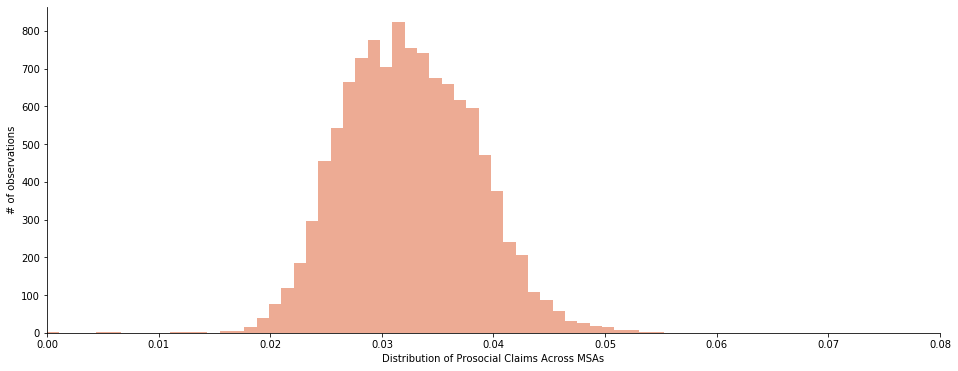

In [16]:
fig, ax = plt.subplots(1,1, figsize=(16, 6))
ax.hist(df_dist_msa['main_dict_mean_mean'], bins=50,  color='#E9967A', alpha=.8)
ax.set_ylabel('# of observations')
ax.set_xlabel('Distribution of Prosocial Claims Across MSAs')
ax.set_xlim([0,.08])

sns.despine()
plt.savefig('msa_dist.pdf', bbox_inches='tight')

In [4]:
df_diff_msa=df_main.groupby(['year_', 'MSA_', 'Employer_']).agg(({'main_dict_mean':['mean'],
                                                                 'main_dict_max':['max'],
                                                                 'main_dict_min':['min'],
                                                                 'main_dict_count':['sum']})).reset_index()
df_diff_msa.columns=['_'.join(col) if type(col) is tuple else col for col in df_diff_msa.columns.values]

In [5]:
df_diff_msa=df_diff_msa.rename(columns={"year__": "year","MSA__": "MSA", "Employer__":"Employer", "main_dict_max_max": "max","main_dict_mean_mean": "mean","main_dict_min_min": "min", "main_dict_count_sum": "count"}, errors="raise")



In [6]:
df_diff_msa2=df_diff_msa.groupby(['year', 'MSA']).agg(({'mean':['mean'],
                                                                 'max':['max'],
                                                                 'min':['min'],
                                                                 'count':['sum']})).reset_index()
df_diff_msa2.columns=['_'.join(col) if type(col) is tuple else col for col in df_diff_msa2.columns.values]

In [7]:
df_diff_msa2['min_max']=df_diff_msa2['max_max']-df_diff_msa2['min_min']

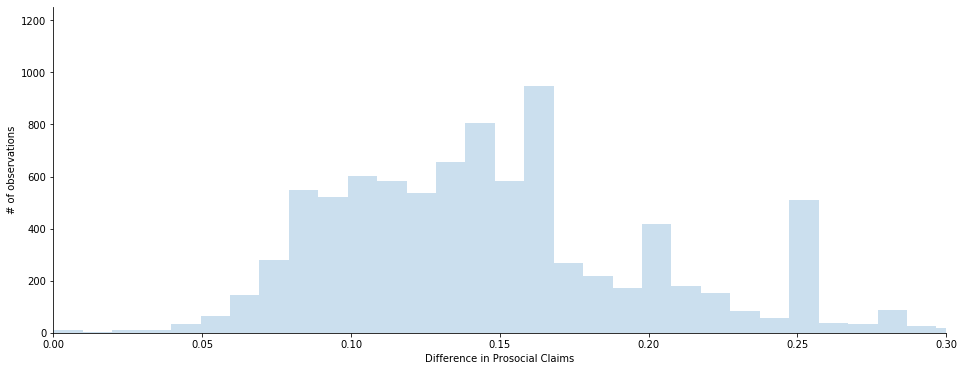

In [32]:
fig, ax = plt.subplots(1,1, figsize=(16, 6))
ax.hist(df_diff_msa2['min_max'], bins=100,  color='#BFD7EA', alpha=.8)
ax.set_ylabel('# of observations')
ax.set_xlabel('Difference in Prosocial Claims')
ax.set_xlim([0,.3])
#ax.set_title('Figure XX: Distribution of Differences in Prosocial Claims Across within Firms, Across Occupations and MSAs'  )

sns.despine()
plt.savefig('diff_within_msa.pdf', bbox_inches='tight')

In [8]:
df_diff_firm=df_diff_msa.groupby(['year', 'Employer']).agg(({'mean':['mean'],
                                                                 'max':['max'],
                                                                 'min':['min'],
                                                                 'count':['sum'],
                                                                    'mean':['count']})).reset_index()
df_diff_firm.columns=['_'.join(col) if type(col) is tuple else col for col in df_diff_firm.columns.values]

In [9]:
df_diff_firm=df_diff_firm[(df_diff_firm.mean_count != 1)]

In [10]:
df_diff_firm['min_max']=df_diff_firm['max_max']-df_diff_firm['min_min']

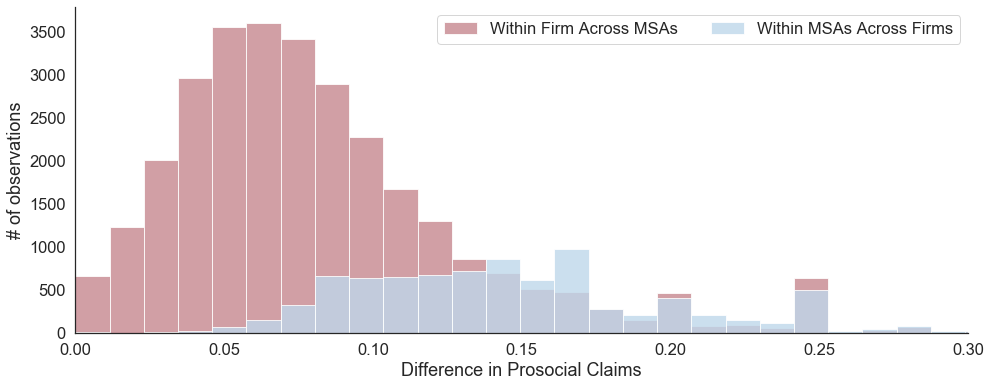

In [15]:
fig, ax = plt.subplots(1,1, figsize=(16, 6))
ax.hist(df_diff_firm['min_max'], bins=2000,  color='#C6878F', alpha=.8, label='Within Firm Across MSAs')
ax.hist(df_diff_msa2['min_max'], bins=2000,  color='#BFD7EA', alpha=.8, label='Within MSAs Across Firms')
ax.legend(loc='upper right', fancybox=True, ncol=3)


ax.set_ylabel('# of observations')
ax.set_xlabel('Difference in Prosocial Claims')
ax.set_xlim([0,.3])
#ax.set_title('Figure XX: Distribution of Differences in Prosocial Claims Across within Firms, Across Occupations and MSAs'  )

sns.despine()
plt.savefig('diff_within_firm.pdf', bbox_inches='tight')

In [16]:
df_diff_occ=df_main.groupby(['year_', 'Employer_', 'OccFamName_', 'MSA_']).agg(({'main_dict_max':['max'],
                                                 'main_dict_min':['min'],
                                                 'main_dict_count':['sum']})).reset_index()
df_diff_occ.columns=['_'.join(col) if type(col) is tuple else col for col in df_diff_occ.columns.values]

In [17]:
df_diff_occ=df_diff_occ.rename(columns={"year__": "year","MSA__": "MSA", "Employer__":"Employer",'OccFamName__':'OccFamName' ,"main_dict_max_max": "max","main_dict_min_min": "min", "main_dict_count_sum": "count"}, errors="raise")



In [18]:
df_diff_occ2=df_diff_occ.groupby(['year', 'Employer', 'OccFamName']).agg(({'max':['max'],
                                                 'min':['min'],
                                                 'count':['sum'],
                                                  'MSA':['count']})).reset_index()
df_diff_occ2.columns=['_'.join(col) if type(col) is tuple else col for col in df_diff_occ2.columns.values]

In [19]:
df_diff_occ2=df_diff_occ2[(df_diff_occ2.MSA_count != 1)]
df_diff_occ2=df_diff_occ2[(df_diff_occ2.OccFamName_ != 'na')]
df_diff_occ2=df_diff_occ2[(df_diff_occ2.Employer_ != 'na')]

In [20]:
df_diff_occ2['min_max']=df_diff_occ2['max_max']-df_diff_occ2['min_min']

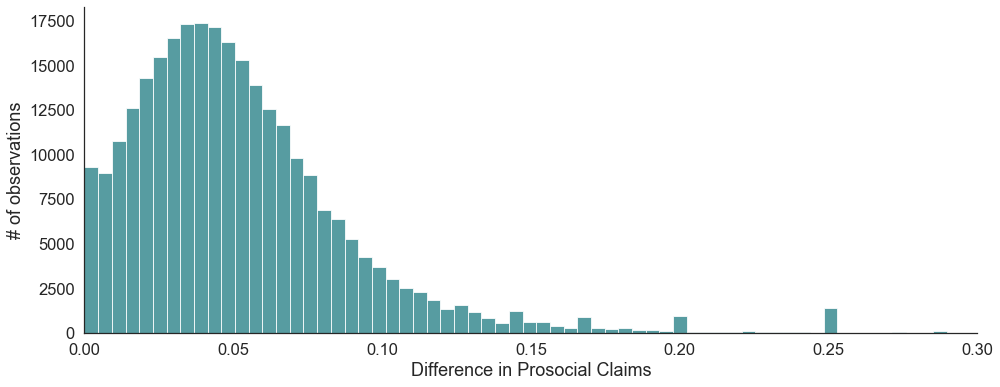

In [22]:
fig, ax = plt.subplots(1,1, figsize=(16, 6))
ax.hist(df_diff_occ2['min_max'], bins=5000,  color='#2D848A', alpha=.8)


ax.set_ylabel('# of observations')
ax.set_xlabel('Difference in Prosocial Claims')
ax.set_xlim([0,.3])
#ax.set_title('Figure XX: Distribution of Differences in Prosocial Claims  within Firms and Occupations, Across MSAs  ')

sns.despine()
plt.savefig('occ_firm_diff.pdf', bbox_inches='tight')

In [110]:
df_main2=df_main

In [113]:
df_main2['NAICS6_'] = df_main2['NAICS6_'].astype(float)


In [115]:
df_main2['NAICS2'] = df_main2['NAICS6_'].astype(str)


In [131]:
df_main2['NAICS2']=df_main2['NAICS2'].str[:2]

In [135]:
df_diff_sec=df_main2.groupby(['year_', 'Employer_', 'NAICS2', 'MSA_']).agg(({'main_dict_max':['max'],
                                                 'main_dict_min':['min'],
                                                 'main_dict_count':['sum']})).reset_index()
df_diff_sec.columns=['_'.join(col) if type(col) is tuple else col for col in df_diff_sec.columns.values]

In [137]:
df_diff_sec=df_diff_sec[(df_diff_sec.NAICS2_ != '-9')]

In [139]:
df_diff_sec=df_diff_sec.rename(columns={"year__": "year","MSA__": "MSA", "Employer__":"Employer",'NAICS2_':'NAICS2' ,"main_dict_max_max": "max","main_dict_min_min": "min", "main_dict_count_sum": "count"}, errors="raise")



In [142]:
df_diff_sec=df_diff_sec.groupby(['year', 'MSA', 'NAICS2']).agg(({'max':['max'],
                                                 'min':['min'],
                                                 'count':['sum'],
                                                  'Employer':['count']})).reset_index()
df_diff_sec.columns=['_'.join(col) if type(col) is tuple else col for col in df_diff_sec.columns.values]

In [151]:
df_diff_sec=df_diff_sec.groupby(['year', 'MSA']).agg(({'max':['max'],
                                                 'min':['min'],
                                                 'count':['sum']})).reset_index()
df_diff_sec.columns=['_'.join(col) if type(col) is tuple else col for col in df_diff_sec.columns.values]

In [148]:
df_diff_sec=df_diff_sec.rename(columns={"year__": "year","MSA__": "MSA", "max_max_max": "max","min_min_min": "min", "count_sum_sum": "count"}, errors="raise")



In [153]:
df_diff_sec['min_max']=df_diff_sec['max_max']-df_diff_sec['min_min']

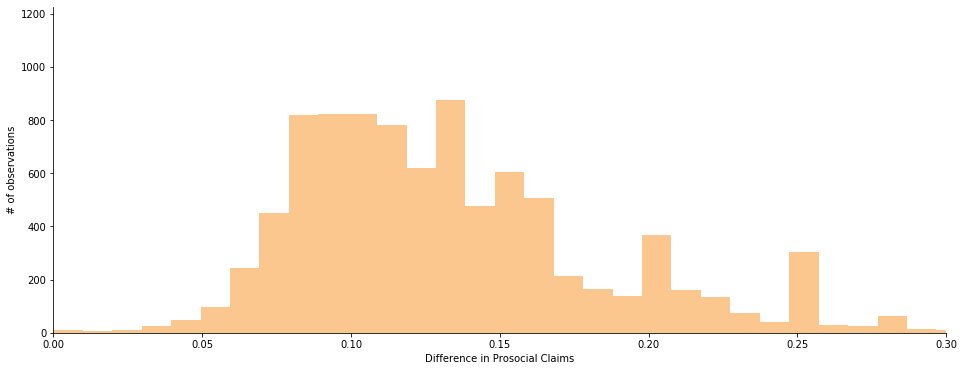

In [156]:
fig, ax = plt.subplots(1,1, figsize=(16, 6))
ax.hist(df_diff_sec['min_max'], bins=100,  color='#FBBA72', alpha=.8)
ax.set_ylabel('# of observations')
ax.set_xlabel('Difference in Prosocial Claims')
ax.set_xlim([0,.3])
#ax.set_title('Figure XX: Distribution of Differences in Prosocial Claims  within Firms and Occupations, Across MSAs  ')

sns.despine()
plt.savefig('sec_msa_diff.pdf', bbox_inches='tight')